<a href="https://colab.research.google.com/github/zamasibalukhulu-d/McDonalds-Share-Price/blob/main/McDonald_Share_Price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**IMPORTING ALL THE LIBRARIES AND DEPENDENCIES**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy

In [2]:
path = '/content/drive/MyDrive/Colab Notebooks/GOOGLE COLAB/MCD.csv'
data = pd.read_csv(path)

In [3]:
data.head()

,Date,Close,High,Low,Open,Volume
0,1/3/2000,21.041384,21.273702,20.676312,21.207325,4520600
1,1/4/2000,20.609928,21.008188,20.377610,20.875434,4216500
2,1/5/2000,20.941809,21.439633,20.609926,20.609926,5231600
3,1/6/2000,20.643116,20.908622,20.543551,20.775869,4809400
4,1/7/2000,21.174128,21.240504,20.643115,20.709492,5124700


In [4]:
data.describe()

,Close,High,Low,Open,Volume
count,6559.000000,6559.000000,6559.000000,6559.000000,6.559000e+03
mean,100.092901,100.838946,99.309031,100.071780,5.355927e+06
std,90.927747,91.569307,90.242097,90.910094,3.426558e+06
min,6.766116,6.859027,6.624016,6.787973,9.632000e+05
25%,20.726666,20.877495,20.479321,20.705098,3.183350e+06
50%,68.244904,68.648625,67.823615,68.205567,4.535200e+06
75%,164.342209,166.380339,162.950638,164.537825,6.500900e+06
max,319.649994,321.790008,318.350006,319.380005,8.698130e+07


In [5]:
# Converted the data to work with
data['Date'] = pd.to_datetime(data['Date'])
data['Year'] = data['Date'].dt.year
print(data.head())

        Date      Close       High        Low       Open   Volume  Year
0 2000-01-03  21.041384  21.273702  20.676312  21.207325  4520600  2000
1 2000-01-04  20.609928  21.008188  20.377610  20.875434  4216500  2000
2 2000-01-05  20.941809  21.439633  20.609926  20.609926  5231600  2000
3 2000-01-06  20.643116  20.908622  20.543551  20.775869  4809400  2000
4 2000-01-07  21.174128  21.240504  20.643115  20.709492  5124700  2000


In [6]:
# Grouping the years and the volumes of the data that is used
year_volumes = data.groupby('Year')['Volume'].sum()

In [7]:
print(year_volumes)

Year
2000    1172940100
2001    1206072800
2002    1532908200
2003    1701588200
2004    1135170100
2005    1571965200
2006    1827609300
2007    1923030000
2008    2553713800
2009    2404392800
2010    1678840200
2011    1701592500
2012    1488658500
2013    1244568500
2014    1382328100
2015    1639297700
2016    1386829600
2017     858809300
2018    1018517600
2019     835862100
2020     982848200
2021     683086500
2022     740614900
2023     674292200
2024     867446200
2025     853751700
2026      62789600
Name: Volume, dtype: int64


Text(0, 0.5, 'Volume(millions)')

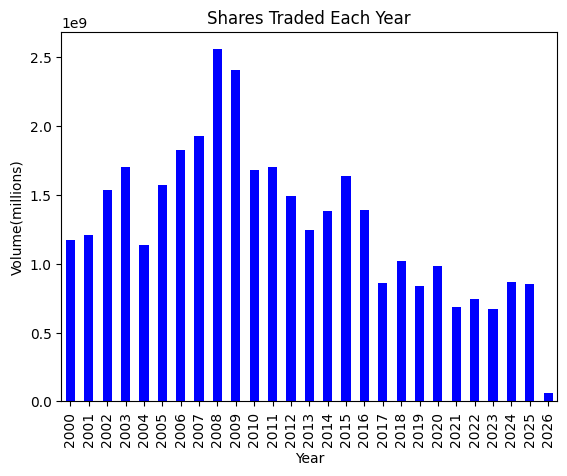

In [8]:
year_volumes.plot(kind = 'bar' ,color=['blue'])
plt.title('Shares Traded Each Year')
plt.ylabel('Volume(millions)')

**THE DECADE OF 2000 TO 2010**

In [9]:
# New dataframe with the year 2000 to 2010
decade_two = data.loc[(data['Year'] >= 2000) & (data['Year'] <= 2010)]

In [10]:
print(decade_two)

           Date      Close       High        Low       Open   Volume  Year
0    2000-01-03  21.041384  21.273702  20.676312  21.207325  4520600  2000
1    2000-01-04  20.609928  21.008188  20.377610  20.875434  4216500  2000
2    2000-01-05  20.941809  21.439633  20.609926  20.609926  5231600  2000
3    2000-01-06  20.643116  20.908622  20.543551  20.775869  4809400  2000
4    2000-01-07  21.174128  21.240504  20.643115  20.709492  5124700  2000
...         ...        ...        ...        ...        ...      ...   ...
2762 2010-12-27  50.986095  51.199566  50.852678  51.186226  2612600  2010
2763 2010-12-28  50.986095  51.106173  50.659220  50.992768  2962900  2010
2764 2010-12-29  51.359665  51.699885  51.119510  51.199563  3583900  2010
2765 2010-12-30  51.206268  51.399727  51.046162  51.272977  2565000  2010
2766 2010-12-31  51.206268  51.272977  50.926084  51.172911  2485100  2010

[2767 rows x 7 columns]


In [11]:
# Looking at the average of the years
avg = decade_two.groupby('Year')['Open'].mean()
print(avg)
# Creating a new series where we can look at the year and the open price
open = decade_two.groupby('Year')['Close'].mean()
print(open)

# How dispersed the data is from the mean.

Year
2000    17.752254
2001    15.182526
2002    13.067170
2003    11.043470
2004    15.476050
2005    18.073219
2006    21.287737
2007    30.240866
2008    35.666430
2009    36.461580
2010    46.540456
Name: Open, dtype: float64
Year
2000    17.743115
2001    15.200552
2002    13.067275
2003    11.054664
2004    15.500828
2005    18.083766
2006    21.303418
2007    30.253000
2008    35.667990
2009    36.447826
2010    46.564185
Name: Close, dtype: float64


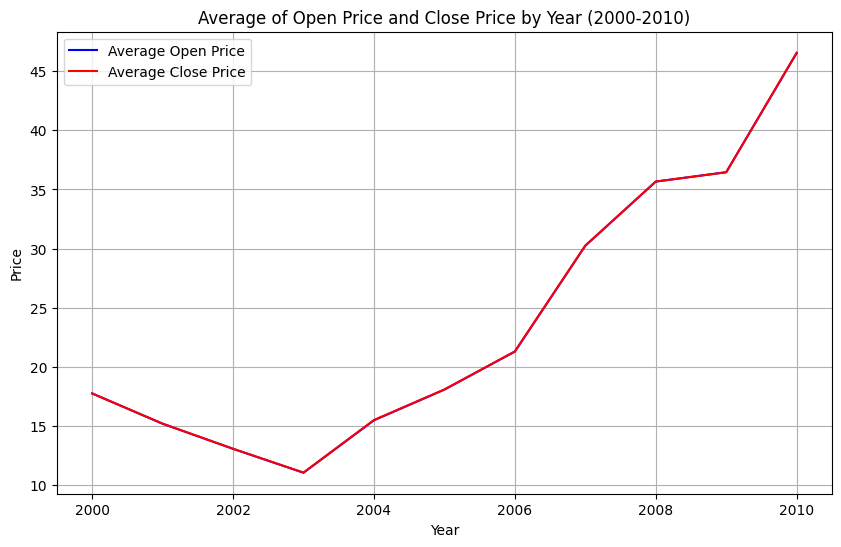

In [12]:
plt.figure(figsize=(10, 6))
avg.plot(kind = 'line', label='Average Open Price', color='blue')
open.plot(kind = 'line', label='Average Close Price', color='red')
plt.title('Average of Open Price and Close Price by Year (2000-2010)')
plt.xlabel('Year')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()
# This shows how the average stock price is not really different from the closing price

In [13]:
# Lookings at the average High and Low Price of the year
high = decade_two.groupby('Year')['High'].mean()
low = decade_two.groupby('Year')['Low'].mean()
print(high,low)

Year
2000    18.050222
2001    15.383504
2002    13.256846
2003    11.183913
2004    15.634701
2005    18.258242
2006    21.457295
2007    30.506352
2008    36.201927
2009    36.805878
2010    46.850289
Name: High, dtype: float64 Year
2000    17.440447
2001    14.988809
2002    12.889456
2003    10.895985
2004    15.355826
2005    17.912018
2006    21.124576
2007    29.976990
2008    35.130572
2009    36.100356
2010    46.242700
Name: Low, dtype: float64


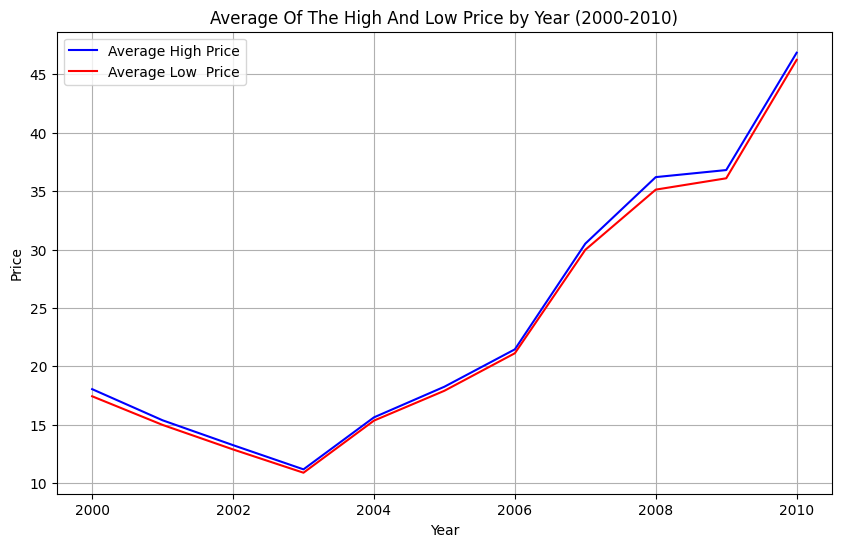

In [14]:
#Plotting the findings to understand better
plt.figure(figsize=(10, 6))
high.plot(kind = 'line', label='Average High Price', color='blue')
low.plot(kind = 'line', label='Average Low  Price', color='red')
plt.title('Average Of The High And Low Price by Year (2000-2010)')
plt.xlabel('Year')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()
# The gap that is noticable is 2008 and it confirms the previous find of the shares trade in the year 2008.

In [24]:
# Looking at the recession that happened in the year 2008
year_2008_data = decade_two[decade_two['Year'] == 2008].copy()
print(year_2008_data)

           Date      Close       High        Low       Open    Volume  Year
2010 2008-01-02  35.241550  36.078614  35.114172  36.078614   7858300  2008
2011 2008-01-03  35.138435  35.666148  35.023188  35.423523   6514700  2008
2012 2008-01-04  34.604641  34.859400  34.228570  34.774481   9687500  2008
2013 2008-01-07  35.199100  35.332546  34.495483  34.792701  10784500  2008
2014 2008-01-08  34.622852  35.569096  34.550063  35.447782  10080800  2008
...         ...        ...        ...        ...        ...       ...   ...
2258 2008-12-24  38.233120  38.470206  37.902449  38.201925   2574800  2008
2259 2008-12-26  38.095860  38.414052  37.952361  38.370378   2410100  2008
2260 2008-12-29  37.671604  38.289272  37.303498  38.052189   5785900  2008
2261 2008-12-30  38.520119  38.526357  37.684081  37.977317   5801000  2008
2262 2008-12-31  38.800877  38.925659  38.258077  38.457727   6230500  2008

[253 rows x 7 columns]


In [27]:
year_2008_data['Month'] = year_2008_data['Date'].dt.month

In [26]:
print(year_2008_data)

           Date      Close       High        Low       Open    Volume  Year  \
2010 2008-01-02  35.241550  36.078614  35.114172  36.078614   7858300  2008   
2011 2008-01-03  35.138435  35.666148  35.023188  35.423523   6514700  2008   
2012 2008-01-04  34.604641  34.859400  34.228570  34.774481   9687500  2008   
2013 2008-01-07  35.199100  35.332546  34.495483  34.792701  10784500  2008   
2014 2008-01-08  34.622852  35.569096  34.550063  35.447782  10080800  2008   
...         ...        ...        ...        ...        ...       ...   ...   
2258 2008-12-24  38.233120  38.470206  37.902449  38.201925   2574800  2008   
2259 2008-12-26  38.095860  38.414052  37.952361  38.370378   2410100  2008   
2260 2008-12-29  37.671604  38.289272  37.303498  38.052189   5785900  2008   
2261 2008-12-30  38.520119  38.526357  37.684081  37.977317   5801000  2008   
2262 2008-12-31  38.800877  38.925659  38.258077  38.457727   6230500  2008   

      Month  
2010      1  
2011      1  
2012     

In [30]:
# Grouping the  volume of the shares in the months
volume_month = year_2008_data.groupby('Month')['Volume'].sum()
print(volume_month)
# Looking at the average open stock per month
open_month = year_2008_data.groupby('Month')['Open'].mean()
print(open_month)
# Ploting the graph of the months in a diagram.


Month
1     322895900
2     173118000
3     176502600
4     162566400
5     130719300
6     170062300
7     199976900
8     187320500
9     235712800
10    340794300
11    222422600
12    231622200
Name: Volume, dtype: int64
Month
1     33.024981
2     33.521197
3     33.275547
4     34.934616
5     36.538553
6     35.825896
7     36.083780
8     38.507483
9     38.774773
10    34.766083
11    34.614321
12    37.812264
Name: Open, dtype: float64


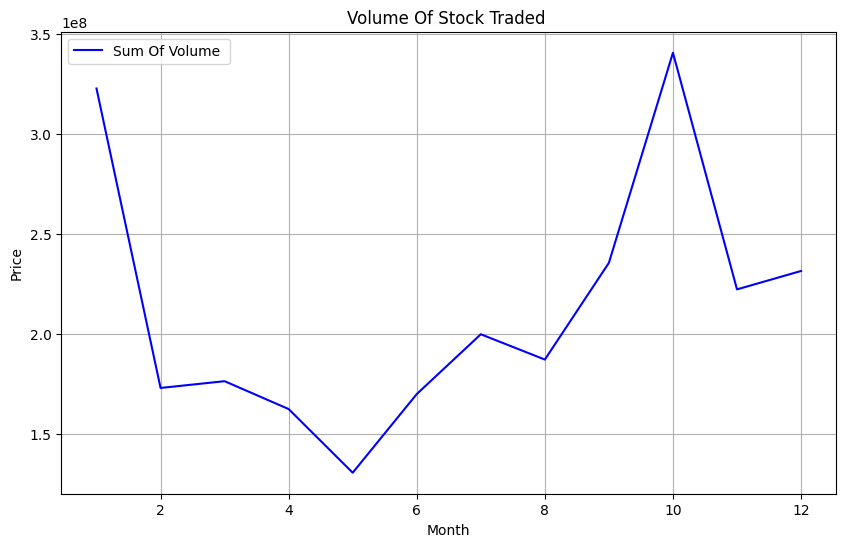

In [34]:
plt.figure(figsize=(10,6))
volume_month.plot(kind = 'line', label='Sum Of Volume ', color='blue')
plt.title('Volume Of Stock Traded ')
plt.xlabel('Month')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()